### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [ ]:
cd /content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26

/content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26


In [ ]:
import os

dataset_dir = '/content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26/data/'
if os.path.exists(dataset_dir):
    print(f"The directory '{dataset_dir}' exists.")
else:
    print(f"The directory '{dataset_dir}' does NOT exist. Please create it and place your dataset files there.")

The directory '/content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26/data/' exists.


### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.6/553.6 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of typer to determine which version is

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

#### Training

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [ ]:
# Single-user training
!python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu trainer.devices=1 \
  --multirun

[2026-03-05 04:12:57,235][HYDRA] Launching 1 jobs locally
[2026-03-05 04:12:57,235][HYDRA] 	#0 : user=single_user trainer.accelerator=gpu trainer.devices=1
[2026-03-05 04:12:57,371][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-st

#### Testing:

- Replace `Your_Path_to_Checkpoint` with your checkpoint path.

In [ ]:
# Single-user testing
!python -m emg2qwerty.train \
  user="single_user" \
  "checkpoint='/content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26/logs/2026-03-05/04-12-57/job0_trainer.devices=1,user=single_user/checkpoints/epoch=28-step=3480.ckpt'" \
  train=False\
  trainer.accelerator=gpu \
  decoder=ctc_greedy \
  # hydra.launcher.mem_gb=64 \
  --multirun


[2026-03-05 04:29:31,441][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

plot the validation CER against the epoch number


In [ ]:
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os

log_dir_LSTM = '/content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26/logs/default-LSTMEncoder/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'
log_dir_GRU = '/content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26/logs/default-GRUEncoder/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'
log_dir_TDSConv = '/content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26/logs/default-TDSConvEncoder/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'

log_dir_all = [log_dir_TDSConv,log_dir_LSTM,log_dir_GRU]
df_metrics_all = []
for log_dir in log_dir_all:

  # List all event files in the directory
  event_files = [os.path.join(log_dir, f) for f in os.listdir(log_dir) if 'events.out.tfevents' in f]

  # Initialize lists to store data
  epoches = []
  val_cers = []

  # Process each event file
  for event_file in event_files:
      event_acc = EventAccumulator(event_file)
      event_acc.Reload()

      # Check if 'val/CER' and 'epoch' tags exist
      if 'val/CER' in event_acc.Tags()['scalars'] and 'epoch' in event_acc.Tags()['scalars']:
          # Get validation CER events
          val_cer_events = event_acc.Scalars('val/CER')
          # Get epoch events
          epoch_events = event_acc.Scalars('epoch')

          # Create a dictionary for quick lookup of epoch by step
          epoch_map = {e.step: int(e.value) for e in epoch_events}

          # Extract CER and corresponding epoch
          for event in val_cer_events:
              if event.step in epoch_map:
                  epoches.append(epoch_map[event.step])
                  val_cers.append(event.value)

  # Create a DataFrame
  df_metrics = pd.DataFrame({
      'epoch': epoches,
      'val/CER': val_cers
  })

  # Drop duplicate epoch entries, keeping the last one (which should be the final CER for that epoch)
  df_metrics = df_metrics.drop_duplicates(subset=['epoch'], keep='last')

  # Sort by epoch
  df_metrics_all = df_metrics.sort_values(by='epoch').reset_index(drop=True)


Extracted metrics from TensorBoard event files:
   epoch      val/CER
0      0  1682.809082
1      1   100.000000
2      2   100.000000
3      3   100.000000
4      4   100.000000


In [ ]:


log_dir_LSTM = '/content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26/logs/default-LSTMEncoder/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'
log_dir_GRU = '/content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26/logs/default-GRUEncoder/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'
log_dir_TDSConv = '/content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26/logs/default-TDSConvEncoder/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'

# Create a list of tuples: (log_directory, model_name)
log_dirs_and_names = [
    (log_dir_TDSConv, 'TDSConvEncoder'),
    (log_dir_LSTM, 'LSTMEncoder'),
    (log_dir_GRU, 'GRUEncoder')
]

df_metrics_all = [] # Initialize as an empty list to collect all DataFrames

for log_dir, model_name in log_dirs_and_names:
  print(f"Processing logs for model: {model_name}")

  # List all event files in the directory
  event_files = [os.path.join(log_dir, f) for f in os.listdir(log_dir) if 'events.out.tfevents' in f]

  # Initialize lists to store data for the current model
  epoches = []
  val_cers = []

  # Process each event file
  for event_file in event_files:
      event_acc = EventAccumulator(event_file)
      event_acc.Reload()

      # Check if 'val/CER' and 'epoch' tags exist
      if 'val/CER' in event_acc.Tags()['scalars'] and 'epoch' in event_acc.Tags()['scalars']:
          # Get validation CER events
          val_cer_events = event_acc.Scalars('val/CER')
          # Get epoch events
          epoch_events = event_acc.Scalars('epoch')

          # Create a dictionary for quick lookup of epoch by step
          epoch_map = {e.step: int(e.value) for e in epoch_events}

          # Extract CER and corresponding epoch
          for event in val_cer_events:
              if event.step in epoch_map:
                  epoches.append(epoch_map[event.step])
                  val_cers.append(event.value)

  # Create a DataFrame for the current model
  df_metrics = pd.DataFrame({
      'epoch': epoches,
      'val/CER': val_cers
  })

  # Drop duplicate epoch entries, keeping the last one
  df_metrics = df_metrics.drop_duplicates(subset=['epoch'], keep='last')

  # Sort by epoch
  df_metrics = df_metrics.sort_values(by='epoch').reset_index(drop=True)

  # Add a 'model_name' column to identify the data source
  df_metrics['model_name'] = model_name

  # Append the DataFrame for the current model to the list
  df_metrics_all.append(df_metrics)

print("\nAll metrics collected in df_metrics_all list.")
# Example of how to access them (e.g., the first DataFrame in the list)
# print(df_metrics_all[0].head())

df_combined_metrics = pd.concat(df_metrics_all, ignore_index=True)
print("Combined Metrics DataFrame Head:")
print(df_combined_metrics.head())

Processing logs for model: TDSConvEncoder
Processing logs for model: LSTMEncoder
Processing logs for model: GRUEncoder

All metrics collected in df_metrics_all list.



Plot the validation CER against the epoch number for each model (TDSConvEncoder, LSTMEncoder, and GRUEncoder) on a single plot, using different colored lines for each model and including a legend, title, and axis labels.

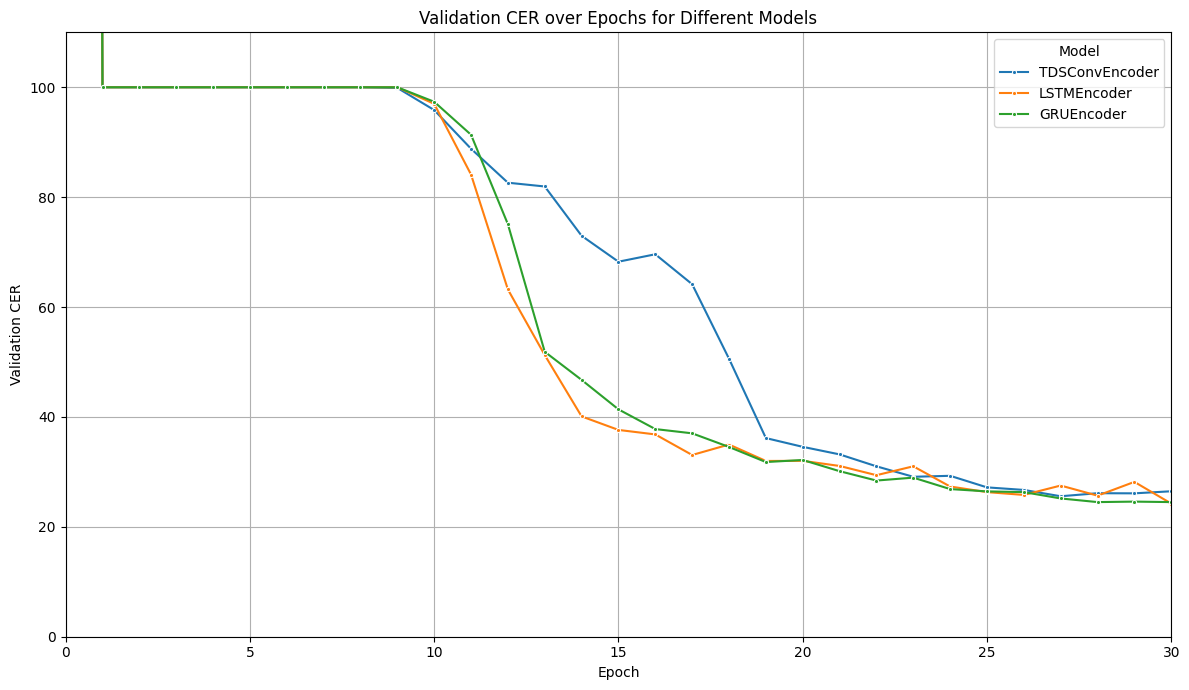

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.lineplot(data=df_combined_metrics, x='epoch', y='val/CER', hue='model_name', marker='.')

plt.title('Validation CER over Epochs for Different Models')
plt.xlabel('Epoch')
plt.ylabel('Validation CER')
plt.grid(True)
plt.xticks(df_combined_metrics['epoch'].unique()[::5]) # Adjust x-axis ticks for readability
plt.legend(title='Model')
plt.xlim([0,30])
plt.ylim([0,110])
plt.tight_layout()
plt.show()